# Pytorch Force Inference Code for Overdamped Persistent Dynamics

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.

This is an adaptation of Billie's force inference code for overdamped persistent cell dynamics, converting it from tensorflow to pytorch for experimental data.

In [1]:
# Enable autoreload so module changes are automatically reloaded
%load_ext autoreload
%autoreload 2

# Import everything from the module
import sys
sys.path.append('..')

import importlib
import torch
import torch.nn as nn

import torch_inference_sims
importlib.reload(torch_inference_sims)
from torch_inference_sims import *
import functorch
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# auto-reload the module

clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
clrs = ['#bfd3e6','#9ebcda','#8c96c6','#8c6bb1','#88419d','#6e016b','#bfd3e6','#9ebcda','#8c96c6','#8c6bb1','#88419d','#6e016b']
clrs0 = ['#cc4c02','#6a51a3','#78c679','#bfd3e6']
cmap = sns.color_palette("viridis", as_cmap=True)


In [2]:
def force_environment_NonLinear(x, y, kappa_x, kappa_y, x_0, y_0, alpha, L=1.0):
    dx = x - x_0
    dy = y - y_0
    # alpha=1 → linear spring, alpha>1 → increasingly nonlinear
    Fx = -kappa_x * np.sign(dx) * (np.abs(dx)/L)**(alpha) * L
    Fy = -kappa_y * np.sign(dy) * (np.abs(dy)/L)**(alpha) * L
    return np.array([Fx, Fy])

## Create and Train Model


In [3]:
class ForceGNN(nn.Module):
    """
    Graph Neural Network for learning force decomposition.
    
    Forces are decomposed into:
    - F_env: Environmental/external forces (position-dependent, uses node_features[:, :2])
    - F_r: Pairwise interaction forces (distance-dependent)
    - Memory/drag term using Jacobian-vector product of F_env and tau_raw
    
    Node features: [x, y, vx, vy, type] - positions, velocities, and particle type
    """
    
    def __init__(self, hidden_dim=32, tau_init=1.0):
        super(ForceGNN, self).__init__()

        self.r_mean = 0.0
        self.r_std  = 1.0
        self.y_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.y_std  = np.array([1.0, 1.0], dtype=np.float32)
        self.x_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.x_std  = float(1.0)
        self.env_net = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
        
        # self.interaction_net = nn.Sequential(
        #     nn.Linear(1, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 1)
        # )
        
        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 2)
        # )

        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim),
        #     nn.SiLU(),                          # SiLU == Swish
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, 2)
        # )
        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim),
        #     nn.SiLU(),                          # SiLU == Swish
        #     nn.LayerNorm(hidden_dim),
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.LayerNorm(hidden_dim),
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, 2)
        # )

        # self.interaction_net = nn.Sequential(
        #     nn.Linear(1, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 1)
        # )

        # Learnable memory timescale
        self.tau_raw = nn.Parameter(
            torch.tensor(tau_init, dtype=torch.float32)
        )

    def _jvp(self, positions, velocities):
        """
        Compute Jacobian-vector product (∂F_env/∂x) · v using
        forward-mode AD via torch.func.jvp.
        
        Parameters:
        -----------
        positions  : (N, 2) position tensor
        velocities : (N, 2) velocity tensor (the tangent vector)
        
        Returns:
        --------
        Jv : (N, 2) JVP result
        """

        def f(pos):
            return self.env_net(pos)

        _, Jv = torch.func.jvp(f, (positions,), (velocities,))
        return Jv

    def forward(self, node_features, edge_indices, edge_features, return_components=False):
        """
        Forward pass of the model.
        
        Parameters:
        -----------
        node_features  : Tensor (N, 5) [x, y, vx, vy, type]
        edge_indices   : Tensor (2, E) edge connections
        edge_features  : Tensor (E, 3) [r, dx/r, dy/r]
        return_components : bool
            If True, return individual force components
        
        Returns:
        --------
        F_total or tuple of (F_total, F_r_aggregated, F_drag, F_env)
        """
        _y = getattr(self, "y_std", 1.0)
        y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
        if y_std == 0.0:
            y_std = 1.0
        
        _x = getattr(self, "x_std", 1.0)
        x_std = float(np.asarray(_x).flat[0]) if np.ndim(_x) != 0 else float(_x)
        if x_std == 0.0:
            x_std = 1.0

        # Extract positions and velocities
        positions  = node_features[:, :2]
        velocities = node_features[:, 2:4]

        # Environmental force
        F_env = self.env_net(positions)

        # # Pairwise interaction force
        # if edge_indices.shape[1] > 0:
        #     edge_distances  = edge_features[:, 0:1]
        #     F_r_scalar      = self.interaction_net(edge_distances)
        #     edge_unit_vectors = edge_features[:, 1:3]
        #     F_r_vector      = F_r_scalar*edge_unit_vectors

        #     target_indices  = edge_indices[1, :]
        #     N = node_features.shape[0]
        #     F_r_aggregated  = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
        #     F_r_aggregated.scatter_add_(
        #         0,
        #         target_indices.long().unsqueeze(1).expand_as(F_r_vector),
        #         F_r_vector
        #     )
        # else:
        #     F_r_aggregated = torch.zeros_like(F_env)

        # (∂F_env/∂x)·v
        #Jv = self._jvp(positions, velocities)

        Jv = self._jvp(positions, velocities)
        vel_term = self.tau_raw*Jv/ x_std  - (1.0/self.tau_raw)*velocities / y_std #self.tau_raw*Jv/ x_std 
        F_drag = vel_term * (2/3)

        # Total force
        F_total = F_drag  + F_env #+ F_r_aggregated

        if return_components:
            return F_total, F_drag, F_env #, F_r_aggregated
        return F_total

In [4]:
def train_model(
    model,
    train_data,
    val_data,
    far_field_reg=0.0,
    far_field_r=70,
    max_r=100.0,
    K_far=1000,
    num_epochs=100,
    learning_rate=1e-3,
    verbose=True,
    eval_before_update=True,
    include_far_field_in_val=False,
    far_field_seed=0,
):
    """
    Train ForceGNN with consistent loss computation and flexible evaluation timing.

    eval_before_update=True:
        reports train/val losses computed on the SAME weights at epoch start.
    eval_before_update=False:
        reports train/val losses after training updates (standard behavior).
    """

    #optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.Adam([
        {'params': [p for n, p in model.named_parameters() if 'tau_raw' not in n],
        'lr': learning_rate},
        {'params': [model.tau_raw], 
        'lr': learning_rate * 20,   # tau explores 10x faster initially
        'name': 'tau_raw'}
    ], lr=learning_rate)

    # Cosine annealing decays tau_raw's lr faster than the network
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=learning_rate * 0.01
    )

    # Normalization attachment
    if len(train_data) > 0 and isinstance(train_data[0], dict):
        dp0 = train_data[0]
        if 'r_mean' in dp0 and 'r_std' in dp0:
            model.r_mean = float(dp0['r_mean'])
            model.r_std  = float(dp0['r_std']) or 1.0
        if 'y_mean' in dp0 and 'y_std' in dp0:
            model.y_mean = np.array(dp0['y_mean'], dtype=np.float32)
            model.y_std  = float(dp0['y_std']) or 1.0
        if 'x_mean' in dp0 and 'x_std' in dp0:
            model.x_mean = np.array(dp0['x_mean'], dtype=np.float32)
            model.x_std  = float(dp0['x_std']) or 1.0
    
    # Loss helpers
    def masked_mse(pred, targ, mask):
        """pred, targ: (N, 2); mask: (N,)"""
        mask = mask.float()
        num = mask.sum()
        if num == 0:
            return torch.tensor(0.0, device=pred.device), torch.tensor(0.0, device=pred.device)
        mask_exp = mask.unsqueeze(1)
        se = (pred - targ).pow(2) * mask_exp
        mse = se.sum() / (num * 2.0)
        return mse, num

    def far_field_penalty(r_far_phys):
        """r_far_phys: (K, 1) in physical units"""
        lam = float(far_field_reg)
        if lam == 0.0:
            return torch.tensor(0.0, device=next(model.parameters()).device)

        r_mean = float(getattr(model, "r_mean", 0.0))
        r_std  = float(getattr(model, "r_std",  1.0))
        if r_std == 0.0:
            r_std = 1.0

        r_far_norm = (r_far_phys - r_mean)/r_std
        F_far = model.interaction_net(r_far_norm)
        return lam*F_far.pow(2).mean()

    def compute_loss_on_dataset(dataset, r_far_phys, include_far):
        total_loss  = 0.0
        total_mse   = 0.0
        total_reg   = 0.0
        total_nodes = 0.0
        n_frames_used = 0

        model.eval()
        with torch.no_grad():
            for dp in dataset:
                if 'mask' in dp and np.sum(dp['mask']) == 0:
                    continue

                pred = model(torch.tensor(dp['nodes']), torch.tensor(dp['edges']), torch.tensor(dp['edge_feat']))
                targ = torch.tensor(dp['targets']).float()

                if 'mask' in dp:
                    mask = torch.tensor(dp['mask'])
                    if not isinstance(mask, torch.Tensor):
                        mask = torch.tensor(mask, dtype=torch.float32, device=pred.device)
                    mse, num = masked_mse(pred, targ, mask)
                    if num.item() == 0:
                        continue
                else:
                    mse = (pred - targ).pow(2).mean()
                    num = torch.tensor(float(pred.shape[0]), device=pred.device)

                reg  = far_field_penalty(r_far_phys) if include_far else torch.tensor(0.0, device=pred.device)
                loss = mse + reg

                n = num.item()
                total_loss  += loss.item() * n
                total_mse   += mse.item()  * n
                total_reg   += reg.item()  * n
                total_nodes += n
                n_frames_used += 1

        if total_nodes == 0:
            return np.nan, np.nan, np.nan, 0, 0

        return (
            total_loss  / total_nodes,
            total_mse   / total_nodes,
            total_reg   / total_nodes,
            int(total_nodes),
            n_frames_used,
        )

    # Training
    def train_step(dp, r_far_phys):
        model.train()
        optimizer.zero_grad()

        pred = model(torch.tensor(dp['nodes']), torch.tensor(dp['edges']), torch.tensor(dp['edge_feat']))
        targ = torch.tensor(dp['targets']).float()

        if 'mask' in dp:
            mask = torch.tensor(dp['mask'])
            if not isinstance(mask, torch.Tensor):
                mask = torch.tensor(mask, dtype=torch.float32, device=pred.device)
            mse, num = masked_mse(pred, targ, mask)
        else:
            mse = (pred - targ).pow(2).mean()
            num = torch.tensor(float(pred.shape[0]), device=pred.device)

        reg  = far_field_penalty(r_far_phys)
        loss = mse + reg

        loss.backward()
        optimizer.step()

        return loss, mse, reg, num

    history = {
        "train_loss": [], "val_loss": [],
        "train_mse":  [], "val_mse":  [],
        "train_reg":  [], "val_reg":  [],
        "tau_raw":    [],
    }

    if verbose:
        print(f"Training for {num_epochs} epochs...")
        print("=" * 60)

    device = next(model.parameters()).device

    for epoch in range(num_epochs):
        r_far_phys = far_field_r + (max_r - far_field_r)*torch.rand(
            K_far, 1, dtype=torch.float32, device=device,
            generator=torch.Generator(device=device).manual_seed(far_field_seed + epoch)
        )
        # Evaluate BEFORE updates
        if eval_before_update:
            trL, trM, trR, trN, trF = compute_loss_on_dataset(train_data, r_far_phys, include_far=True)
            vaL, vaM, vaR, vaN, vaF = compute_loss_on_dataset(val_data,   r_far_phys, include_far=include_far_field_in_val)
        else:
            trL = trM = trR = vaL = vaM = vaR = None

        # Train one epoch
        total_loss  = 0.0
        total_mse   = 0.0
        total_reg   = 0.0
        total_nodes = 0.0

        for dp in train_data:
            if 'mask' in dp and np.sum(dp['mask']) == 0:
                continue

            loss, mse, reg, num = train_step(dp, r_far_phys)
            n = num.item()
            if n == 0:
                continue

            total_loss  += loss.item() * n
            total_mse   += mse.item()  * n
            total_reg   += reg.item()  * n
            total_nodes += n

        train_loss_after = (total_loss / total_nodes) if total_nodes > 0 else np.nan
        train_mse_after  = (total_mse  / total_nodes) if total_nodes > 0 else np.nan
        train_reg_after  = (total_reg  / total_nodes) if total_nodes > 0 else np.nan
        
        # Evaluate AFTER updates
        if not eval_before_update:
            trL, trM, trR, _, _ = compute_loss_on_dataset(train_data, r_far_phys, include_far=True)
            vaL, vaM, vaR, _, _ = compute_loss_on_dataset(val_data,   r_far_phys, include_far=include_far_field_in_val)
        scheduler.step()
        history["train_loss"].append(trL)
        history["val_loss"].append(vaL)
        history["train_mse"].append(trM)
        history["val_mse"].append(vaM)
        history["train_reg"].append(trR)
        history["val_reg"].append(vaR)
        history["tau_raw"].append(
            model.tau_raw.item() if hasattr(model, 'tau_raw') else np.nan
        )

        if verbose and (epoch % 10 == 0 or epoch == num_epochs - 1):
            tau_lr = optimizer.param_groups[1]['lr']
            #print(f"... Tau_raw={tau_val:.6f}, Tau_lr={tau_lr:.6f}")
            timing = "PRE" if eval_before_update else "POST"
            tau_val = model.tau_raw.item() if hasattr(model, 'tau_raw') else float('nan')
            print(
                f"Epoch {epoch:3d} [{timing}-update metrics]: "
                f"Train L={trL:.6f} (mse={trM:.6f}, reg={trR:.6f}) | "
                f"Val L={vaL:.6f} (mse={vaM:.6f}, reg={vaR:.6f}) | "
                f"Train-step avg(after)={train_loss_after:.6f} | "
                f"Tau_raw={tau_val:.6f}, Tau_lr={tau_lr:.6f}"
            )

    return model, history

In [5]:
def create_model(hidden_dim=32, tau_init=1.0):
    """
    Create a ForceGNN model.
    
    Parameters:
    -----------
    hidden_dim : int
        Hidden dimension for neural network layers
    
    Returns:
    --------
    ForceGNN
        Initialized model
    """
    model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)
    print(f"ForceGNN model created with hidden_dim={hidden_dim}")
    return model

In [6]:
# import pickle
# save_path = Path("/Users/billiemeadowcroft/Dropbox/PostDocCode/SeanData/for_billie/dataIN/")  # or your scratch dir
# nameSave_DataIN = "FenvOnly_tau1_kappa0.5.pkl"

# with open(save_path / nameSave_DataIN, "rb") as f:
#     data_loaded = pickle.load(f)

# dataset = data_loaded["dataset"]
# meta = data_loaded["meta"]
# train_frac = 0.7
# val_frac = 0.3
# test_frac = 0.0
# train_data_, val_data_, test_data_, all_data_ = split_dataset(dataset)

        

In [ ]:
# Prepare dataset with graph structure
datasave = "//Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/ForDuke/OD_Inference/models/"

temp = 0.1 #0.1
numframes = 300
seed = 1
tau_mem0=10
frame = 100 #200
NumEpochs = 100
kappa0 = 0.5 #0.3
gamma0 = 1 #3 #1/20
epsilon = 0.0
alpha = 1.5 #,2.5] #,2.0,2.5
delta_t = 0.001

folder = ''

dataname = "output_PersistentFrames_alpha1.5_box_size100_epsilon0.0_frame100kappa0.5_Gamma1_Tau10Sig1.1N100seed1_Temp0.1_NumFrames300.csv"

datadir='//Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/ForDuke/Simulations/Outputs/'
data = load_data(datadir, dataname)

#data = load_data(AltUD_Data, name)

dt = delta_t*frame
T_weak = False
T_Naive = True
tau = 16
print("length of data: ", len(data))
print("Total unique particles: ", len(data['particle'].unique()))
print("for naive derivative, should be losing 2x the number of particles",len(data)-len(data['particle'].unique())*2)
min_frame = data['frame'].min()
max_frame = data['frame'].max()
#data = data[data['frame'] > max_frame-140]
data_clean = calculate_derivatives(data, dt=dt,weak_form = T_weak,naive_form = T_Naive,tau = tau)
dataset_ = prepare_dataset(data_clean, cutoff=3.0, max_frames=700,use_neighbor_list=False)
train_data, val_data, test_data, __ = split_dataset(dataset_)

Data loaded: (29900, 7)
Columns: ['frame', 'particle', 'type', 'x', 'y', 'z', 'sumForce']
Number of frames: 299
length of data:  29900
Total unique particles:  100
for naive derivative, should be losing 2x the number of particles 29700
Calculating derivatives...
Processing 100 particles...
Calculating naïve derivatives...
Acceleration statistics:
  ax: mean=0.000, std=1.111
  ay: mean=0.002, std=1.125
Preparing dataset from 299 frames...
processing frame  0.0
processing frame  1.0
processing frame  2.0
processing frame  3.0
processing frame  4.0
processing frame  5.0
processing frame  6.0
processing frame  7.0
processing frame  8.0
processing frame  9.0
processing frame  10.0
processing frame  11.0
processing frame  12.0
processing frame  13.0
processing frame  14.0
processing frame  15.0
processing frame  16.0
processing frame  17.0
processing frame  18.0
processing frame  19.0
processing frame  20.0
processing frame  21.0
processing frame  22.0
processing frame  23.0
processing frame

In [10]:
# Create model
model = create_model(hidden_dim=64, tau_init=10)

# Train model
Epochs = 300
far_field_strength = 0.0
far_field_r = 3.0
max_r = 4.0
K_far = 1
model, history = train_model(model,train_data,val_data,far_field_reg=far_field_strength,far_field_r=far_field_r,max_r=max_r,K_far=K_far,num_epochs=Epochs,learning_rate=1e-3,verbose=True,include_far_field_in_val=False,far_field_seed=1)

#model, history = train_model(model, train_data, val_data, num_epochs=100)


ForceGNN model created with hidden_dim=64
Training for 300 epochs...
Epoch   0 [PRE-update metrics]: Train L=1.010565 (mse=1.010565, reg=0.000000) | Val L=1.038480 (mse=1.038480, reg=0.000000) | Train-step avg(after)=0.979021 | Tau_raw=9.078100, Tau_lr=0.019999
Epoch  10 [PRE-update metrics]: Train L=0.972343 (mse=0.972343, reg=0.000000) | Val L=1.002283 (mse=1.002283, reg=0.000000) | Train-step avg(after)=0.972505 | Tau_raw=9.778122, Tau_lr=0.019934
Epoch  20 [PRE-update metrics]: Train L=0.969847 (mse=0.969847, reg=0.000000) | Val L=0.999516 (mse=0.999516, reg=0.000000) | Train-step avg(after)=0.970652 | Tau_raw=10.269256, Tau_lr=0.019759
Epoch  30 [PRE-update metrics]: Train L=0.969436 (mse=0.969436, reg=0.000000) | Val L=0.998478 (mse=0.998478, reg=0.000000) | Train-step avg(after)=0.970220 | Tau_raw=10.174863, Tau_lr=0.019478
Epoch  40 [PRE-update metrics]: Train L=0.969272 (mse=0.969272, reg=0.000000) | Val L=0.998081 (mse=0.998081, reg=0.000000) | Train-step avg(after)=0.969930 

In [11]:
# temp = 0.1 #0.1
# numframes = 300 #300
# seed = 1
# tau_mem0=10
# frame = 100
# NumEpochs = 100
# #output_Persistent_alpha2.0_epsilon0_frame100kappa0_Gamma3_Tau1Sig1.1N100seed1_Temp0.1_NumFrames300
# kappa0 = 0.5
# gamma0 = 1
# A = kappa0/(gamma0*tau_mem0)
# B = -(np.divide(kappa0,gamma0)+np.divide(1,tau_mem0))
# C = 1
# # tau is solution of A*tau + B*tau + C = 0
# tau_sol1 = np.divide(-B + np.sqrt(B**2 - 4*A*C),2*A)
# tau_sol2 = np.divide(-B - np.sqrt(B**2 - 4*A*C),2*A)
# print("tau_sol1",tau_sol1)
# print("tau_sol2",tau_sol2)


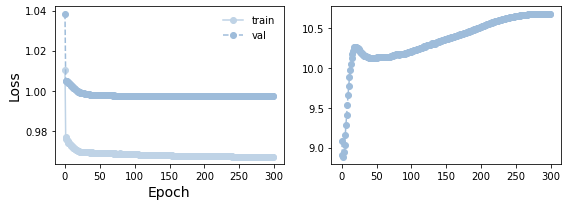

In [12]:
# Plot training history
tau_mem0=10
gamma0=1

fig,ax  = plt.subplots(1,2,figsize = (8,3))
ax[0].plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train',marker = 'o')
ax[0].plot(history['val_loss'],color = clrs[1],linestyle = '--',label = 'val',marker = 'o')
ax[1].plot(history['tau_raw'],color = clrs[1],linestyle = '--',label = 'tau',marker = 'o')
#ax[1].plot([0,len(history['tau_raw'])],[tau_mem0,tau_mem0],color = 'black',linestyle = '--',label = r"True force gradient $\nabla_x F$")
ax[0].legend(frameon = False)
ax[0].set_xlabel('Epoch',fontsize = 14)
ax[0].set_ylabel('Loss',fontsize = 14)
fig.tight_layout()

In [13]:
def get_force_environment(model, x, y):
    if not hasattr(model, 'env_net') or model.env_net is None:
        raise AttributeError(
            "This model does not have an env_net (F_env component). "
            "The model was trained without environmental forces."
        )

    x_mean = np.array(getattr(model, "x_mean", [0.0, 0.0]), dtype=np.float32)
    x_std  = float(getattr(model, "x_std", 1.0))
    if x_std == 0.0:
        x_std = 1.0

    # Normalise query position
    x_norm = (float(x) - float(x_mean[0])) / x_std
    y_norm = (float(y) - float(x_mean[1])) / x_std

    model.eval()
    with torch.no_grad():
        inp = torch.tensor([[x_norm, y_norm]], dtype=torch.float32,
                           device=next(model.parameters()).device)
        F_env_norm = model.env_net(inp).cpu().numpy()[0, :]

    # De-normalise output to physical units
    _y = getattr(model, "y_std", 1.0)
    y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
    if y_std == 0.0:
        y_std = 1.0

    return y_std * F_env_norm

1 10 0.5
-2.000416820701583
i 0
i 1
i 2
i 3
i 4
i 5
i 6
i 7
i 8
i 9


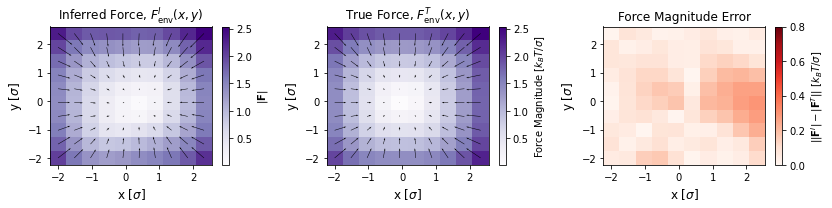

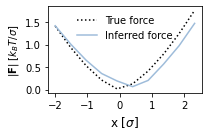

In [18]:
kappa0=0.5
kappa_x,kappa_y = kappa0,kappa0
x_0,y_0 = 0,0
L=1
print(gamma0,tau_mem0,kappa0)
center = np.array([0,0])
x_arr = np.linspace(data['x'].min()/1.5,data['x'].max()/1.5,10)
y_arr = np.linspace(data['y'].min()/1.5,data['y'].max()/1.5,10)
print(x_arr[0])
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')
F_env_infer = np.zeros((len(x_arr),len(y_arr),2))
F_env_true = np.zeros((len(x_arr),len(y_arr),2))
for i,x in enumerate(x_arr):
    print("i",i)
    for j,y in enumerate(y_arr):
        F_env_infer[i,j,:] = get_force_environment(model , x, y)*tau_mem0*gamma0
        F_env_true[i,j] = force_environment_NonLinear(x,y,kappa_x,kappa_y,x_0,y_0,alpha,L) #arbitrary_force(x,y,kappa_y,center,A_x,L_x) #
F_mag = np.linalg.norm(F_env_infer, axis=2)  # shape (len(x_arr), len(y_arr))
F_mag_true = np.linalg.norm(F_env_true, axis=2)  # shape (len(x_arr), len(y_arr))


# Count datapoints per bin
counts, x_edges, y_edges = np.histogram2d(
    data['x'], data['y'],
    bins=[len(x_arr), len(y_arr)],
    range=[[x_arr[0], x_arr[-1]], [y_arr[0], y_arr[-1]]]
)
# counts[i, j] = number of datapoints in bin (i, j)
# Mask bins with <= 10 datapoints
sparse_mask = counts <= 10  # shape (len(x_arr), len(y_arr))

F_mag_masked = np.where(sparse_mask, np.nan, F_mag)
F_mag_true_masked = np.where(sparse_mask, np.nan, F_mag_true)

# Create coordinate grid (note indexing='ij' to match F_env_infer[i,j,:])
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')

fig,ax  = plt.subplots(1,3,figsize = (7.8*1.5,3))


# pcm = ax[0].pcolormesh(X, Y, F_mag, shading='auto', cmap='Purples',vmin =np.min(F_mag_true),vmax = np.max(F_mag_true))
# cbar = fig.colorbar(pcm, ax=ax[0])
# cbar.set_label(r'$|\mathbf{F}|$')

# # === 3) Quiver on top ===
# # (optional) downsample arrows so the plot isn’t too busy
sx = max(len(x_arr) // 20, 1)
sy = max(len(y_arr) // 20, 1)

# Mask quiver arrows where data is sparse
quiver_u = np.where(sparse_mask, np.nan, F_env_infer[:, :, 0])
quiver_v = np.where(sparse_mask, np.nan, F_env_infer[:, :, 1])

pcm = ax[0].pcolormesh(X, Y, F_mag_masked, shading='auto', cmap='Purples',
                        vmin=np.min(F_mag_true), vmax=np.max(F_mag_true))
cbar = fig.colorbar(pcm, ax=ax[0])
cbar.set_label(r'$|\mathbf{F}|$')

ax[0].quiver(
    X[::sx, ::sy], Y[::sx, ::sy],
    quiver_u[::sx, ::sy], quiver_v[::sx, ::sy],
    color='k', angles='xy', scale_units='xy', scale=None, width=0.003
)



# === 4) Axes labels / ticks ===
ax[0].set_xlabel(r'x [$\sigma$]',fontsize = 12)
ax[0].set_ylabel(r'y [$\sigma$]',fontsize = 12)

ax[0].set_title(r'Inferred Force, $F^I_{\mathrm{env}}(x,y)$')

pcm = ax[1].pcolormesh(X, Y, F_mag_true_masked, shading='auto', cmap='Purples',vmin =np.min(F_mag_true),vmax = np.max(F_mag_true))
cbar = fig.colorbar(pcm, ax=ax[1])
cbar.set_label(r'Force Magnitude $[k_B T/\sigma]$')

quiver_u = np.where(sparse_mask, np.nan, F_env_true[:, :, 0])
quiver_v = np.where(sparse_mask, np.nan, F_env_true[:, :, 1])
ax[1].quiver(
    X[::sx, ::sy],
    Y[::sx, ::sy],
    quiver_u[::sx, ::sy], quiver_v[::sx, ::sy],
    color='k',  # arrows in black; background carries magnitude
    angles='xy',
    scale_units='xy',
    scale=None,   # or a number if you want to shrink arrows
    width=0.003
)
ax[1].set_title(r'True Force, $F^T_{\mathrm{env}}(x,y)$',fontsize = 12)

ax[1].set_xlabel(r'x [$\sigma$]',fontsize = 12)
ax[1].set_ylabel(r'y [$\sigma$]',fontsize = 12)

F_err_masked = np.where(sparse_mask, np.nan, np.abs(F_mag - F_mag_true))

pcm = ax[2].pcolormesh(X, Y, F_err_masked, shading='auto', cmap='Reds',
                        vmin=0, vmax=0.8)
cbar = fig.colorbar(pcm, ax=ax[2])
cbar.set_label(r'$||\mathbf{F}^I| - |\mathbf{F}^T||$ $[k_B T/\sigma]$')
ax[2].set_title(r'Force Magnitude Error')
ax[2].set_xlabel(r'x [$\sigma$]', fontsize=12)
ax[2].set_ylabel(r'y [$\sigma$]', fontsize=12)
name = "NonLinearForceInference_Alpha2.0_s3_NoFenv"
fig.tight_layout()
#fig.savefig('Plots/'+name+'.png',dpi=600)

fig2,ax2  = plt.subplots(figsize = (3,2))
ax2.plot(x_arr, F_mag_true[:,4],linestyle = ':',color = 'black',label = "True force")
ax2.plot(x_arr, F_mag[:,4],color = clrs[1],label = "Inferred force")
ax2.legend(frameon=False)
ax2.set_xlabel(r'x [$\sigma$]',fontsize = 12)
ax2.set_ylabel(r'$|\mathbf{F}|$ $[k_B T/\sigma]$')

name = "NonLinearForceInference_Alpha2.0_s3_NoFenv_Xaxis"
fig2.tight_layout()
#fig2.savefig('Plots/'+name+'.png',dpi=600)



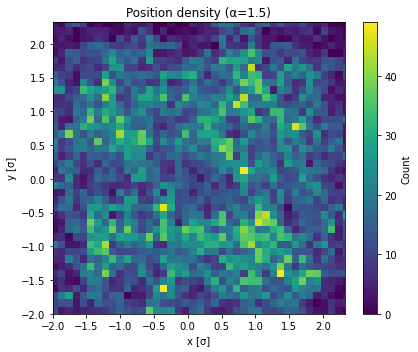

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
_, _, _, im = ax.hist2d(data['x'], data['y'], bins=60, cmap='viridis') #, vmin=0, vmax=100)
fig.colorbar(im, ax=ax, label='Count')
ax.set_xlabel('x [σ]')
ax.set_ylabel('y [σ]')
ax.set_ylim([x_arr[0], x_arr[-1]])
ax.set_xlim([x_arr[0], x_arr[-1]])
ax.set_title(f'Position density (α={alpha})')
fig.tight_layout()
fig.savefig('density_heatmap.png', dpi=150)

In [20]:
# fetch the predicted and true force along the trajectory
Forces_inferred_x = []
Forces_inferred_y = []
Forces_true_x = []
Forces_true_y = []
x_0,y_0 = 0,0
kappa_x,kappa_y = kappa0,kappa0
rel_errors = []
data_eval = data[data['frame'] < 2000]

# before the loop
all_true_x = [force_environment_NonLinear(x,y,kappa_x,kappa_y,x_0,y_0,alpha,L)[0] 
              for x,y in zip(data_eval['x'], data_eval['y'])]
all_true_y = [force_environment_NonLinear(x,y,kappa_x,kappa_y,x_0,y_0,alpha,L)[1] 
              for x,y in zip(data_eval['x'], data_eval['y'])]
rms_force = np.sqrt(np.mean(np.array(all_true_x)**2 + np.array(all_true_y)**2))
epsilon_reg = 0.05 * rms_force

for i in range(len(data_eval['x'])):
    x = data_eval['x'][i]
    y = data_eval['y'][i]
    F_env_infer_x,F_env_infer_y = get_force_environment(model, x, y)*tau_mem0*gamma0
    F_env_true_x,F_env_true_y = force_environment_NonLinear(x,y,kappa_x,kappa_y,x_0,y_0,alpha,L)
    Forces_inferred_x.append(F_env_infer_x)
    Forces_inferred_y.append(F_env_infer_y)
    Forces_true_x.append(F_env_true_x)
    Forces_true_y.append(F_env_true_y)
    err_x = F_env_infer_x - F_env_true_x
    err_y = F_env_infer_y - F_env_true_y
    err_norm = np.add(err_x**2,err_y**2)
    true_force_mag = np.add(F_env_true_x**2,F_env_true_y**2)
    if true_force_mag > 0.3*0.3:
       rel_errors.append(err_norm/true_force_mag)

    # err_mag = np.sqrt(err_x**2 + err_y**2)
    # true_mag = np.sqrt(F_env_true_x**2 + F_env_true_y**2)
    # # Normalise by true mag + small fraction of RMS force across dataset
    # #rms_force = np.sqrt(np.mean(np.array(Forces_true_x)**2 + np.array(Forces_true_y)**2))
    # #epsilon_reg = 0.05 * rms_force  # 5% of typical force scale
    # rel_errors.append(err_mag / (true_mag + epsilon_reg))
    
print("median rel error",np.median(rel_errors))
print("mean rel error",np.mean(rel_errors))

median rel error 0.03061308178189046
mean rel error 0.0597691004256114
